In [164]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [165]:
df = pd.read_json("baikal_data.json")
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")
df.head()

Строк: 1100, Столбцов: 10


,ID,Животное,Тип,Место наблюдения,Сезон,Количество особей,Температура воздуха (°C),Тип питания,Антропогенный фактор,Интересный факт
0,1,Омуль,рыба,Чивыркуйский залив,весна,83.0,-5.945668,всеядный,загрязнение,"Символ Байкала, нерестится в реках осенью"
1,2,Голомянка,рыба,Чивыркуйский залив,осень,224.0,9.245049,хищник,загрязнение,Уникальная живородящая рыба с прозрачным телом
2,3,Чайка,птица,Селенгинский район,зима,1.0,-19.465447,хищник,нет влияния,"Гнездится колониями на скалах, питается рыбой"
3,4,Нерпа,млекопитающее,Селенгинский район,осень,6.0,14.569795,хищник,загрязнение,"Единственное млекопитающее Байкала, может ныря..."
4,5,Чайка,птица,Ольхон,осень,3.0,-3.955328,хищник,рыболовство,"Гнездится колониями на скалах, питается рыбой"


In [166]:
df.info()

<class 'pandas.DataFrame'>
Index: 1100 entries, 0 to 1099
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        1100 non-null   int64  
 1   Животное                  1100 non-null   str    
 2   Тип                       1100 non-null   str    
 3   Место наблюдения          1100 non-null   str    
 4   Сезон                     1100 non-null   str    
 5   Количество особей         1099 non-null   float64
 6   Температура воздуха (°C)  1097 non-null   float64
 7   Тип питания               1100 non-null   str    
 8   Антропогенный фактор      1100 non-null   str    
 9   Интересный факт           1100 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 94.5 KB


#### Первое знакомство с данными
  1. ID — Уникальный номер записи.
  2. Животное — Вид животного.
  3. Тип — Биологический класс/группа.
  4. Место наблюдения — Локация встречи.
  5. Сезон — Время года.
  6. Количество особей — Число замеченных животных.
  7. Температура воздуха (°C) — Температура при наблюдении.
  8. Тип питания — Пищевая специализация.
  9. Антропогенный фактор — Влияние человека.
  10. Интересный факт — Особенность вида.

In [167]:
display(df.describe())

,ID,Количество особей,Температура воздуха (°C)
count,1100.000000,1099.000000,1097.000000
mean,550.500000,985.754322,-1.605929
std,317.686953,2329.403210,12.794733
min,1.000000,0.000000,-24.932808
25%,275.750000,8.000000,-12.694100
50%,550.500000,85.000000,-1.773593
75%,825.250000,330.500000,10.296396
max,1100.000000,14817.000000,19.981301


In [168]:
num_data = ["ID", "Количество особей", "Температура воздуха (°C)"]
for col in num_data:
  categorical_data = []
  if df[col].shape[0] / len(df[col].unique()) < 0.01:
    categorical_data.append(col)
print(categorical_data)

[]


#### Типы данных
  1. String — Животное, Тип, Место наблюдения, Сезон, Тип питания, Антропогенный фактор, Интересный факт.
  2. Float (Числовые) — Количество особей, Температура воздуха (°C).   

In [169]:
print(f"Всего пропусков {int(df.isna().sum().sum())}")

Всего пропусков 4


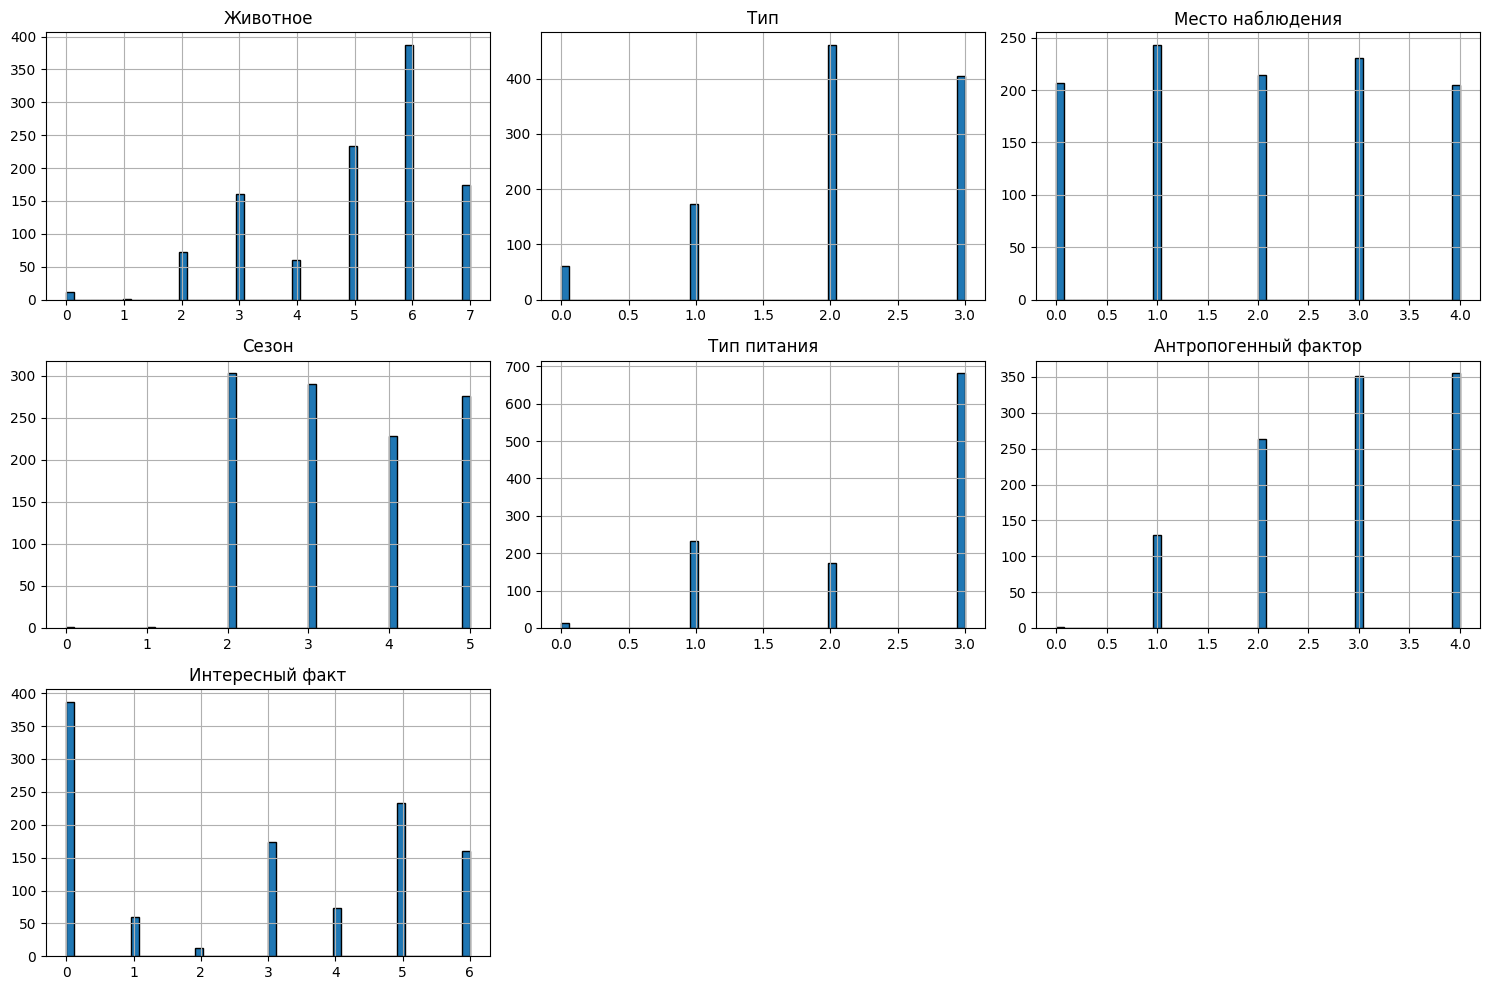

Колонка — Животное
['Байкальский осетр', 'Баклан', 'Большой баклан', 'Голомянка', 'Нерпа', 'Омуль', 'Чайка', 'Эпишура']
--------------------------------------------------
Колонка — Тип
['млекопитающее', 'планктон', 'птица', 'рыба']
--------------------------------------------------
Колонка — Место наблюдения
['Баргузинский залив', 'Малое Море', 'Ольхон', 'Селенгинский район', 'Чивыркуйский залив']
--------------------------------------------------
Колонка — Сезон
['Лето', 'Осень', 'весна', 'зима', 'лето', 'осень']
--------------------------------------------------
Колонка — Тип питания
['бентофаг', 'всеядный', 'фильтратор', 'хищник']
--------------------------------------------------
Колонка — Антропогенный фактор
['НЕТ', 'загрязнение', 'нет влияния', 'рыболовство', 'туристы']
--------------------------------------------------
Колонка — Интересный факт
['Гнездится колониями на скалах, питается рыбой', 'Единственное млекопитающее Байкала, может нырять на 300 метров!', 'Занесен в Красную

In [170]:
def data_categ_visualization(df, num_data):
  df_copy = df.copy()
  
  for col in df_copy.columns:
    if col in num_data:
      df_copy = df_copy.drop(col, axis=1)
    else:
      lb = LabelEncoder()
      df_copy[col] = lb.fit_transform(df_copy[col].astype(str))
      
  df_copy.hist(figsize=(15, 10), bins=50, edgecolor='black')
  plt.tight_layout()
  plt.show()

def print_data(df, num_data):
  for col in df.columns:
    if col not in num_data:
      print(f'Колонка — {col}')
      print(sorted(df[col].astype(str).unique())) 
      print("-" * 50)

data_categ_visualization(df, num_data)
print_data(df, num_data)

##### В колонках сезон, животное, тип питания мы видим странные значения которые нужно будет проверить

1. В колонке **Сезон** наблюдается проблема: значения «лето» и «осень» записаны в разном регистре.
2. В колонке **Животное** присутствуют дублирующие категории: «баклан» и «Большой баклан». Судя по графикам, записей «Большой баклан» значительно больше, вероятно, стоит их объединить.
3. В колонке **Антропогенный фактор** присуствует значение "НЕТ" и "Нет влияния". По графику мы видим что "НЕТ", встречается очень малое кол-во раз. 
4. В колонке **Тип питания** очень мало бентофагов. Это выглядит логично, так как они реже встречаются в природе.

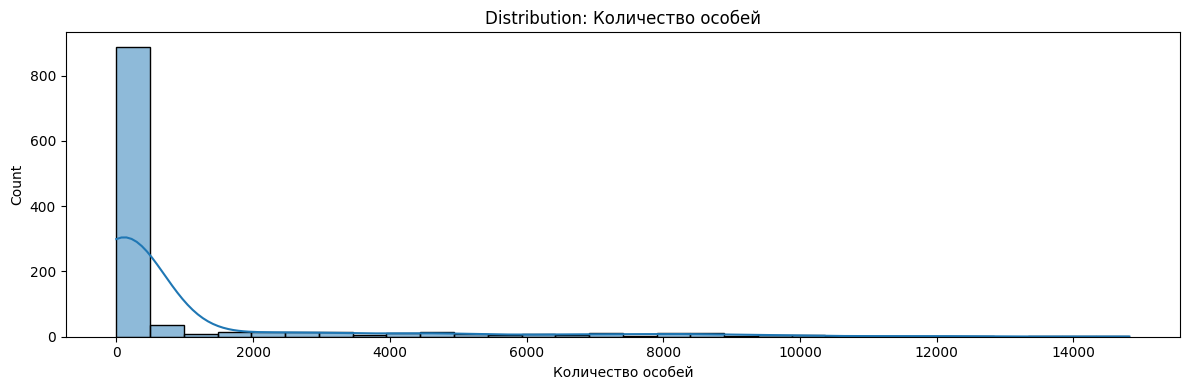

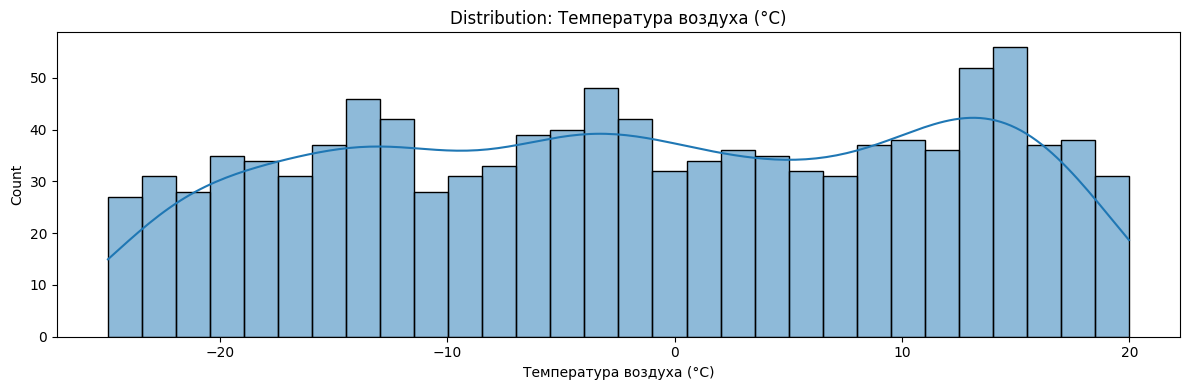

In [171]:
def data_num_visualization(df, num_cols):
    cols_to_plot = [col for col in num_cols if col != "ID"]
    
    for col in cols_to_plot:
        plt.figure(figsize=(12, 4))

        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Distribution: {col}')
        
        plt.tight_layout()
        plt.show()

data_num_visualization(df, num_data)

#### Анализ распределения числовых данных

1. **Количество особей**:
   - Распределение сильно скошено влево (Right-skewed).
   - Основная масса наблюдений — одиночные особи или малые группы (0–500).
   - "Длинный хвост" до 14 000 указывает на наличие выбросов — вероятно, массовые виды (планктон, стаи рыб), в отличие от одиночных животных.

2. **Температура воздуха**:
   - Распределение мультимодальное (несколько пиков), что подтверждает сезонность наблюдений.
   - Четко видны кластеры отрицательных (зима/весна) и положительных (лето/осень) температур.
   - Экстремальных аномалий (например, +50°C или -80°C) не наблюдается, данные выглядят реалистично.

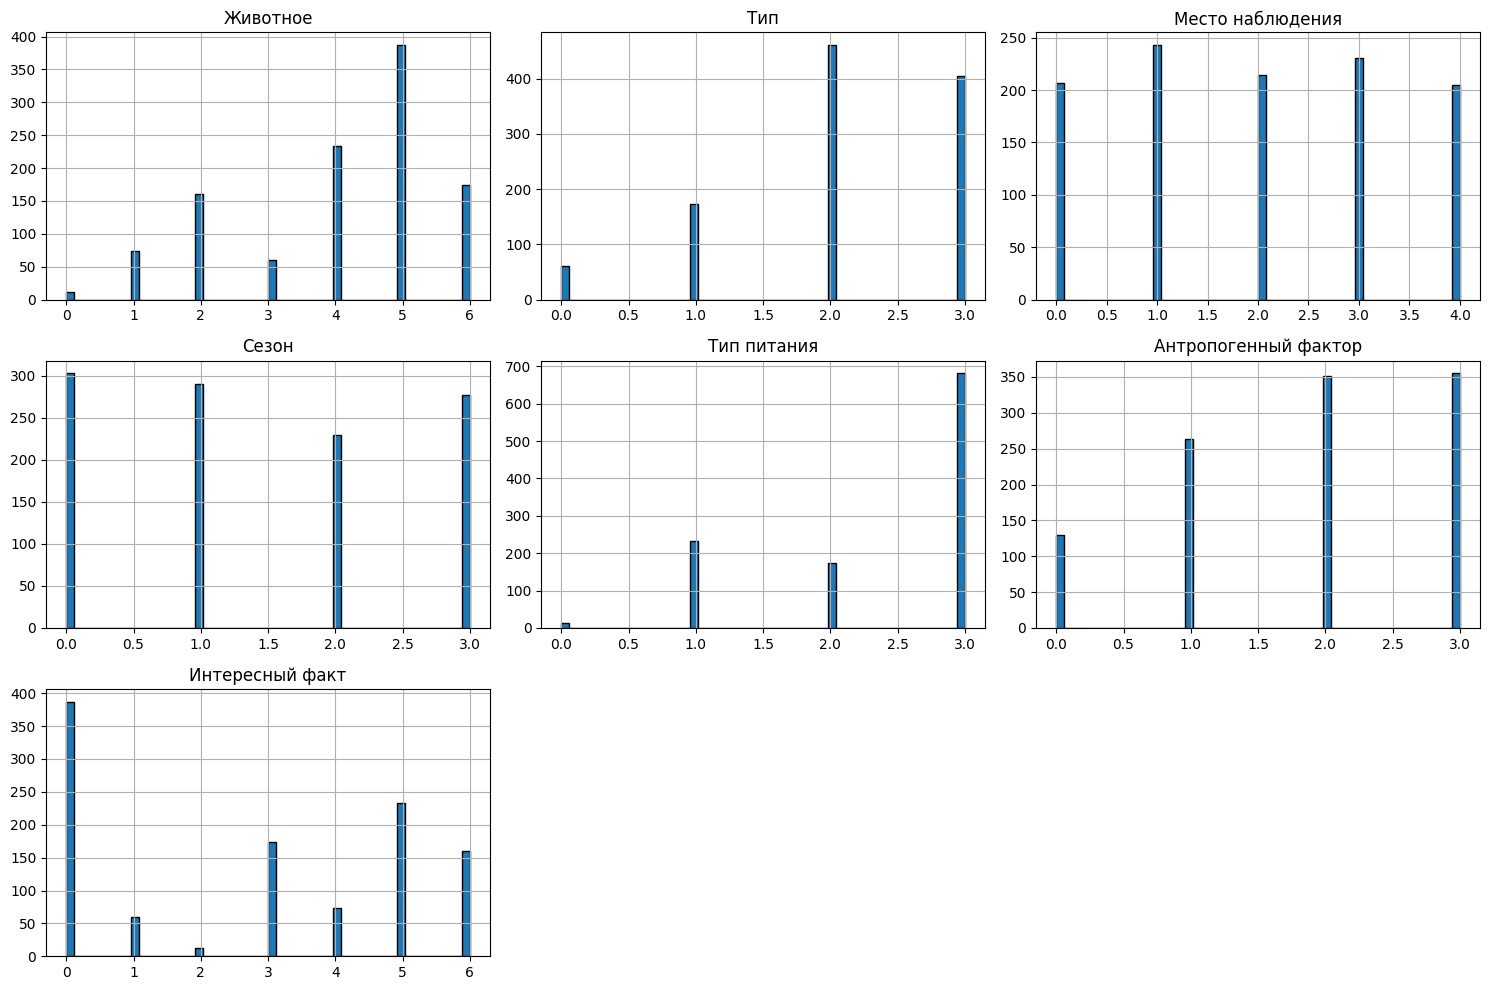

Колонка — Животное
['Байкальский осетр', 'Большой баклан', 'Голомянка', 'Нерпа', 'Омуль', 'Чайка', 'Эпишура']
--------------------------------------------------
Колонка — Тип
['млекопитающее', 'планктон', 'птица', 'рыба']
--------------------------------------------------
Колонка — Место наблюдения
['Баргузинский залив', 'Малое Море', 'Ольхон', 'Селенгинский район', 'Чивыркуйский залив']
--------------------------------------------------
Колонка — Сезон
['весна', 'зима', 'лето', 'осень']
--------------------------------------------------
Колонка — Тип питания
['бентофаг', 'всеядный', 'фильтратор', 'хищник']
--------------------------------------------------
Колонка — Антропогенный фактор
['загрязнение', 'нет влияния', 'рыболовство', 'туристы']
--------------------------------------------------
Колонка — Интересный факт
['Гнездится колониями на скалах, питается рыбой', 'Единственное млекопитающее Байкала, может нырять на 300 метров!', 'Занесен в Красную книгу, встречается крайне редко',

In [172]:
df['Сезон'] = df['Сезон'].str.lower()
df.loc[df['Животное'] == 'Баклан', 'Животное'] = 'Большой баклан' 
df.loc[df["Антропогенный фактор"] == "НЕТ", "Антропогенный фактор"] = "нет влияния"

df = df.fillna(df.max()) # Так как у нас всего 4 пропуска заменим на самое частое значени
data_categ_visualization(df, num_data)
print_data(df, num_data)

In [173]:
df_copy = df.copy()
for col in df:
  for num_col in num_data:
    if num_col != col:
      lb = LabelEncoder()
      df_copy[col] = lb.fit_transform(df_copy[col])


In [174]:
for col in num_data:
  if col in df_copy.columns:
      df_copy = df_copy.drop(col, axis=1)

